# 1A – Classification (Solved)
Complete end‑to‑end workflow for molecular classification using fingerprints and sklearn models.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from rdkit import Chem
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt


## Load data

In [2]:
df = pd.read_csv("ames_data.csv")
df.head()

,drug_id,smiles,mutagenicity
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


## Clean data

In [4]:
# Initial inspection
print(df.info())
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# Basic cleaning
df = df.dropna().drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7278 entries, 0 to 7277
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   drug_id       7278 non-null   object
 1   smiles        7278 non-null   object
 2   mutagenicity  7278 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 170.7+ KB
None
Missing values: 0
Duplicates: 0


## Convert SMILES → Morgan fingerprints

In [5]:
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    # Morgan Fingerprint (Circular) with radius 2 and 2048 bits
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.zeros((0,), dtype=np.int8)
    # RDKit utility to convert bit vector to numpy array
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Apply to generate X and y
X = np.array([smiles_to_fp(s) for s in df['smiles']])
y = df['mutagenicity'].values

[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerator
[22:53:49] DEPRECATION WARNING: please use MorganGenerat

## Train / Test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Models

In [8]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

## Train + evaluate

In [9]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"{name} -> Accuracy: {accuracy_score(y_test, y_pred):.3f}, ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

KNN -> Accuracy: 0.812, ROC-AUC: 0.883
DecisionTree -> Accuracy: 0.780, ROC-AUC: 0.778
RandomForest -> Accuracy: 0.839, ROC-AUC: 0.916
GradientBoosting -> Accuracy: 0.784, ROC-AUC: 0.860


## Confusion matrix (best model)

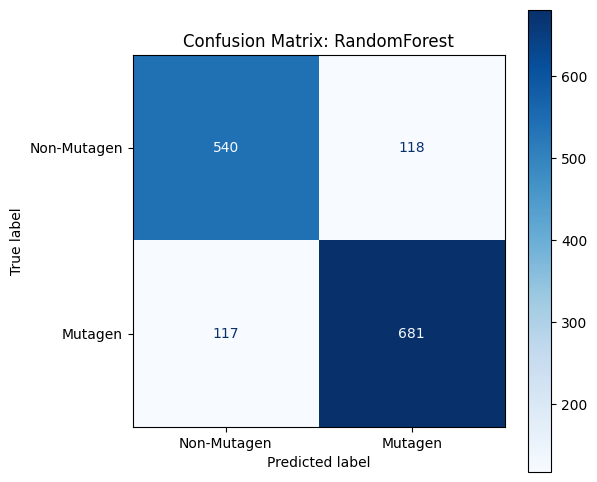

Confusion Matrix for RandomForest:
[[540 118]
 [117 681]]


In [12]:
best_model_name = "RandomForest"
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Mutagen', 'Mutagen'])
disp.plot(cmap='Blues', ax=ax)

plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

# Print the specific counts
print(f"Confusion Matrix for {best_model_name}:")
print(cm)